# ML Volatility Forecasting — Can ML Beat GARCH(1,1)?

**Question:** Given the same information GARCH uses (plus standard volatility features), can an ML model forecast next-day realized volatility more accurately than GARCH's own conditional volatility formula?

This is an empirical test of a known, actively contested question in financial econometrics, applied to NSE equity data. GARCH serves two roles here:
1. **Baseline** — the benchmark forecast to beat
2. **Feature** — `garch_vol` is one of 11 input features to the ML models

**Target:** 5-day forward realized volatility (continuous, not binary)

**Models:** GARCH(1,1) baseline → Ridge regression sanity check → XGBoost regressor

**Evaluation:** QLIKE loss (primary), MSE (secondary), validated with TimeSeriesSplit (5 folds)

---
*Separate from the ML Violation Predictor (binary classifier) documented elsewhere in this repo. That experiment used a different target shape and is preserved as a documented negative result.*

## 1. Data Loading & Target Construction

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ticker = "RELIANCE.NS"
start = "2018-01-01"
end = "2026-05-01"

data = yf.download(ticker, start=start, end=end, progress=False)

if isinstance(data.columns, pd.MultiIndex):
    price = data["Close"][ticker]
else:
    price = data["Close"]

price = price.squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

print(f"Loaded {len(log_returns)} trading days")
print(f"Period: {log_returns.index[0].date()} to {log_returns.index[-1].date()}")

Loaded 2055 trading days
Period: 2018-01-02 to 2026-04-30


In [4]:
# Target: 5-day forward realized volatility
# shift(-1) makes this a forward-looking label — never used as a feature
target = log_returns.shift(-1).rolling(5).std()
target.name = "realized_vol_5d"

print(f"Target stats:")
print(f"  Mean:   {target.mean():.6f}")
print(f"  Median: {target.median():.6f}")
print(f"  Std:    {target.std():.6f}")
print(f"  Non-NaN count: {target.notna().sum()}")

Target stats:
  Mean:   0.014688
  Median: 0.012754
  Std:    0.009593
  Non-NaN count: 2050


## 2. Feature Construction (11 features, all properly lagged)

In [6]:
df = pd.DataFrame(index=log_returns.index)
df['returns'] = log_returns

# Return features (lagged — no leakage)
df['return_lag1'] = df['returns'].shift(1)
df['return_lag2'] = df['returns'].shift(2)
df['rolling_return_5d'] = df['returns'].shift(1).rolling(5).mean()
df['rolling_return_20d'] = df['returns'].shift(1).rolling(20).mean()

# Volatility features (lagged)
df['rolling_vol_5d'] = df['returns'].shift(1).rolling(5).std()
df['rolling_vol_20d'] = df['returns'].shift(1).rolling(20).std()
df['rolling_vol_60d'] = df['returns'].shift(1).rolling(60).std()
df['vol_ratio'] = df['rolling_vol_5d'] / df['rolling_vol_60d']

# GARCH(1,1) conditional volatility
scaled = log_returns * 100
garch_model = arch_model(scaled, vol='Garch', p=1, q=1, mean='Constant', dist='normal')
garch_result = garch_model.fit(disp='off')
cond_vol = garch_result.conditional_volatility / 100

# shift(1) — use yesterday's GARCH estimate, not today's
df['garch_vol'] = cond_vol.shift(1)
df['garch_vol_change'] = df['garch_vol'].pct_change()

# Max drawdown over past 5 days
df['max_drawdown_5d'] = df['returns'].shift(1).rolling(5).min().abs()

# Attach target
df['target'] = target

print(f"GARCH parameters:")
print(f"  omega = {garch_result.params['omega']:.6f}")
print(f"  alpha = {garch_result.params['alpha[1]']:.6f}")
print(f"  beta  = {garch_result.params['beta[1]']:.6f}")
print(f"\nDataFrame shape before cleaning: {df.shape}")
print(df.head(65).tail(5))

GARCH parameters:
  omega = 0.134486
  alpha = 0.095047
  beta  = 0.859363

DataFrame shape before cleaning: (2055, 13)
             returns  return_lag1  return_lag2  rolling_return_5d  \
Date                                                                
2018-04-03  0.007364     0.011545    -0.019187          -0.003376   
2018-04-04 -0.005183     0.007364     0.011545           0.001260   
2018-04-05  0.014753    -0.005183     0.007364          -0.001381   
2018-04-06  0.003078     0.014753    -0.005183           0.001858   
2018-04-09  0.005473     0.003078     0.014753           0.006311   

            rolling_return_20d  rolling_vol_5d  rolling_vol_20d  \
Date                                                              
2018-04-03           -0.003335        0.013793         0.014174   
2018-04-04           -0.002644        0.012391         0.014350   
2018-04-05           -0.001605        0.011990         0.013286   
2018-04-06           -0.000146        0.013990         0.0134

In [7]:
# Clean: drop rows with any NaN (from rolling windows + forward target)
feature_cols = [
    'return_lag1', 'return_lag2',
    'rolling_return_5d', 'rolling_return_20d',
    'rolling_vol_5d', 'rolling_vol_20d', 'rolling_vol_60d',
    'vol_ratio',
    'garch_vol', 'garch_vol_change',
    'max_drawdown_5d'
]

df_clean = df.dropna(subset=feature_cols + ['target']).copy()

X = df_clean[feature_cols]
y = df_clean['target']

print(f"Clean dataset: {len(df_clean)} rows, {len(feature_cols)} features")
print(f"Period: {df_clean.index[0].date()} to {df_clean.index[-1].date()}")
print(f"\nFeature columns: {feature_cols}")
print(f"\nLeakage check — target uses shift(-1), features use shift(+1):")
print(f"  First feature date: {X.index[0].date()}")
print(f"  Last target date:   {y.index[-1].date()}")

Clean dataset: 1994 rows, 11 features
Period: 2018-04-03 to 2026-04-29

Feature columns: ['return_lag1', 'return_lag2', 'rolling_return_5d', 'rolling_return_20d', 'rolling_vol_5d', 'rolling_vol_20d', 'rolling_vol_60d', 'vol_ratio', 'garch_vol', 'garch_vol_change', 'max_drawdown_5d']

Leakage check — target uses shift(-1), features use shift(+1):
  First feature date: 2018-04-03
  Last target date:   2026-04-29


## 3. GARCH Baseline Benchmark

GARCH's own conditional volatility forecast is the number everything else has to beat. We evaluate it against the realized-vol target using QLIKE and MSE — the same metrics applied to all models.

In [9]:
def qlike_loss(y_true, y_pred):
    """QLIKE loss — standard in vol-forecasting literature.
    Operates on variances. Penalizes underestimating volatility more heavily."""
    var_true = y_true ** 2
    var_pred = y_pred ** 2
    # Clip to avoid log(0) or division by zero
    var_pred = np.clip(var_pred, 1e-12, None)
    return np.mean(var_true / var_pred - np.log(var_true / var_pred) - 1)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# GARCH baseline: its forecast is garch_vol, already in df_clean
garch_forecast = df_clean['garch_vol']

garch_qlike = qlike_loss(y.values, garch_forecast.values)
garch_mse = mse_loss(y.values, garch_forecast.values)

print("=" * 50)
print("GARCH(1,1) BASELINE")
print("=" * 50)
print(f"  QLIKE: {garch_qlike:.6f}")
print(f"  MSE:   {garch_mse:.10f}")
print(f"\nThis is the number to beat.")

GARCH(1,1) BASELINE
  QLIKE: 0.355497
  MSE:   0.0000513064

This is the number to beat.


## 4. Ridge Regression — Sanity Check

Before adding complexity, verify that a simple linear model can even improve on GARCH. If Ridge can't beat it, XGBoost probably won't either (or if it does, the gap is likely noise).

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

ridge_fold_results = []
garch_fold_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)
    ridge_pred = np.clip(ridge_pred, 1e-8, None)

    garch_pred_fold = df_clean['garch_vol'].iloc[test_idx].values

    ridge_fold_results.append({
        'fold': fold + 1,
        'qlike': qlike_loss(y_test.values, ridge_pred),
        'mse': mse_loss(y_test.values, ridge_pred),
        'test_start': y_test.index[0].date(),
        'test_end': y_test.index[-1].date(),
        'n_test': len(y_test)
    })
    garch_fold_results.append({
        'fold': fold + 1,
        'qlike': qlike_loss(y_test.values, garch_pred_fold),
        'mse': mse_loss(y_test.values, garch_pred_fold)
    })

ridge_df = pd.DataFrame(ridge_fold_results)
garch_df = pd.DataFrame(garch_fold_results)

print("RIDGE vs GARCH — Fold-by-Fold Comparison")
print("=" * 70)
for i in range(5):
    r = ridge_df.iloc[i]
    g = garch_df.iloc[i]
    qlike_diff = ((r['qlike'] - g['qlike']) / g['qlike']) * 100
    print(f"Fold {int(r['fold'])} ({r['test_start']} → {r['test_end']}, n={int(r['n_test'])})")
    print(f"  GARCH QLIKE: {g['qlike']:.6f}  |  Ridge QLIKE: {r['qlike']:.6f}  |  Δ: {qlike_diff:+.1f}%")
    print(f"  GARCH MSE:   {g['mse']:.10f}  |  Ridge MSE:   {r['mse']:.10f}")
    print()

print("-" * 70)
print(f"Mean QLIKE — GARCH: {garch_df['qlike'].mean():.6f}  |  Ridge: {ridge_df['qlike'].mean():.6f}")
print(f"Mean MSE   — GARCH: {garch_df['mse'].mean():.10f}  |  Ridge: {ridge_df['mse'].mean():.10f}")
ridge_wins = (ridge_df['qlike'].values < garch_df['qlike'].values).sum()
print(f"\nRidge wins {ridge_wins}/5 folds on QLIKE")

RIDGE vs GARCH — Fold-by-Fold Comparison
Fold 1 (2019-08-09 → 2020-12-11, n=332)
  GARCH QLIKE: 0.441013  |  Ridge QLIKE: 0.373814  |  Δ: -15.2%
  GARCH MSE:   0.0001339359  |  Ridge MSE:   0.0001093288

Fold 2 (2020-12-14 → 2022-04-18, n=332)
  GARCH QLIKE: 0.288431  |  Ridge QLIKE: 0.262912  |  Δ: -8.8%
  GARCH MSE:   0.0000355557  |  Ridge MSE:   0.0000271847

Fold 3 (2022-04-19 → 2023-08-17, n=332)
  GARCH QLIKE: 0.300875  |  Ridge QLIKE: 0.268419  |  Δ: -10.8%
  GARCH MSE:   0.0000306280  |  Ridge MSE:   0.0000267369

Fold 4 (2023-08-18 → 2024-12-24, n=332)
  GARCH QLIKE: 0.465075  |  Ridge QLIKE: 0.346245  |  Δ: -25.6%
  GARCH MSE:   0.0000451888  |  Ridge MSE:   0.0000280923

Fold 5 (2024-12-26 → 2026-04-29, n=332)
  GARCH QLIKE: 0.342805  |  Ridge QLIKE: 0.251684  |  Δ: -26.6%
  GARCH MSE:   0.0000273061  |  Ridge MSE:   0.0000161888

----------------------------------------------------------------------
Mean QLIKE — GARCH: 0.367640  |  Ridge: 0.300615
Mean MSE   — GARCH: 0.000

## 5. XGBoost Regressor — Main ML Model

In [13]:
tscv = TimeSeriesSplit(n_splits=5)

xgb_fold_results = []
xgb_predictions = pd.Series(dtype=float, name='xgb_pred')
ridge_predictions = pd.Series(dtype=float, name='ridge_pred')

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_pred = np.clip(xgb_pred, 1e-8, None)

    xgb_predictions = pd.concat([xgb_predictions, pd.Series(xgb_pred, index=y_test.index)])

    # Also store Ridge predictions for the plot later
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train)
    r_pred = np.clip(ridge.predict(X_test_scaled), 1e-8, None)
    ridge_predictions = pd.concat([ridge_predictions, pd.Series(r_pred, index=y_test.index)])

    garch_pred_fold = df_clean['garch_vol'].iloc[test_idx].values

    xgb_fold_results.append({
        'fold': fold + 1,
        'qlike': qlike_loss(y_test.values, xgb_pred),
        'mse': mse_loss(y_test.values, xgb_pred),
        'test_start': y_test.index[0].date(),
        'test_end': y_test.index[-1].date(),
        'n_test': len(y_test)
    })

xgb_df = pd.DataFrame(xgb_fold_results)

print("XGBOOST vs RIDGE vs GARCH — Fold-by-Fold Comparison")
print("=" * 80)
for i in range(5):
    x = xgb_df.iloc[i]
    r = ridge_df.iloc[i]
    g = garch_df.iloc[i]
    print(f"Fold {int(x['fold'])} ({x['test_start']} → {x['test_end']}, n={int(x['n_test'])})")
    print(f"  QLIKE — GARCH: {g['qlike']:.6f}  |  Ridge: {r['qlike']:.6f}  |  XGBoost: {x['qlike']:.6f}")
    print(f"  MSE   — GARCH: {g['mse']:.10f}  |  Ridge: {r['mse']:.10f}  |  XGBoost: {x['mse']:.10f}")
    print()

print("=" * 80)
print("MEAN ACROSS FOLDS")
print(f"  QLIKE — GARCH: {garch_df['qlike'].mean():.6f}  |  Ridge: {ridge_df['qlike'].mean():.6f}  |  XGBoost: {xgb_df['qlike'].mean():.6f}")
print(f"  MSE   — GARCH: {garch_df['mse'].mean():.10f}  |  Ridge: {ridge_df['mse'].mean():.10f}  |  XGBoost: {xgb_df['mse'].mean():.10f}")

xgb_wins_garch = (xgb_df['qlike'].values < garch_df['qlike'].values).sum()
xgb_wins_ridge = (xgb_df['qlike'].values < ridge_df['qlike'].values).sum()
print(f"\nXGBoost wins {xgb_wins_garch}/5 folds vs GARCH on QLIKE")
print(f"XGBoost wins {xgb_wins_ridge}/5 folds vs Ridge on QLIKE")

XGBOOST vs RIDGE vs GARCH — Fold-by-Fold Comparison
Fold 1 (2019-08-09 → 2020-12-11, n=332)
  QLIKE — GARCH: 0.441013  |  Ridge: 0.373814  |  XGBoost: 0.570806
  MSE   — GARCH: 0.0001339359  |  Ridge: 0.0001093288  |  XGBoost: 0.0001771377

Fold 2 (2020-12-14 → 2022-04-18, n=332)
  QLIKE — GARCH: 0.288431  |  Ridge: 0.262912  |  XGBoost: 0.254932
  MSE   — GARCH: 0.0000355557  |  Ridge: 0.0000271847  |  XGBoost: 0.0000290110

Fold 3 (2022-04-19 → 2023-08-17, n=332)
  QLIKE — GARCH: 0.300875  |  Ridge: 0.268419  |  XGBoost: 0.263291
  MSE   — GARCH: 0.0000306280  |  Ridge: 0.0000267369  |  XGBoost: 0.0000248359

Fold 4 (2023-08-18 → 2024-12-24, n=332)
  QLIKE — GARCH: 0.465075  |  Ridge: 0.346245  |  XGBoost: 0.363694
  MSE   — GARCH: 0.0000451888  |  Ridge: 0.0000280923  |  XGBoost: 0.0000267643

Fold 5 (2024-12-26 → 2026-04-29, n=332)
  QLIKE — GARCH: 0.342805  |  Ridge: 0.251684  |  XGBoost: 0.265126
  MSE   — GARCH: 0.0000273061  |  Ridge: 0.0000161888  |  XGBoost: 0.0000174485

MEA

## 6. Feature Importance & Diagnosis

Which features matter most? If `garch_vol` dominates, the ML model is essentially just recalibrating GARCH's own output — useful but not surprising. If other features add real signal, the nonlinear combination captures something GARCH's parametric form misses.

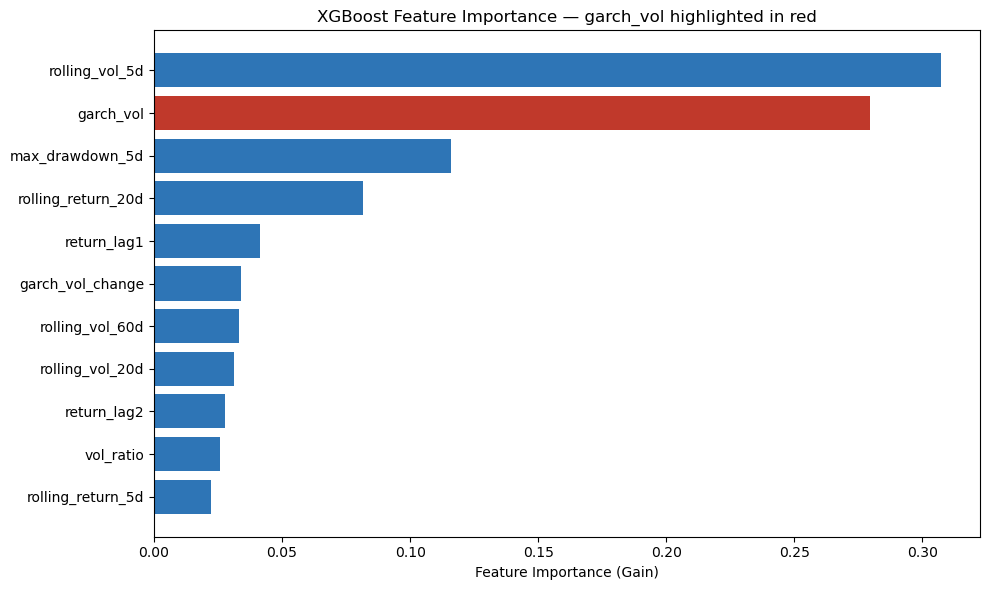


Feature importance ranking:
  rolling_vol_5d            0.3071
  garch_vol                 0.2794 ← GARCH baseline feature
  max_drawdown_5d           0.1159
  rolling_return_20d        0.0817
  return_lag1               0.0415
  garch_vol_change          0.0340
  rolling_vol_60d           0.0332
  rolling_vol_20d           0.0314
  return_lag2               0.0277
  vol_ratio                 0.0258
  rolling_return_5d         0.0224


In [15]:
# Retrain XGBoost on full dataset for feature importance
xgb_full = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_full.fit(X, y)

importances = pd.Series(xgb_full.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#c0392b' if feat == 'garch_vol' else '#2e75b6' for feat in importances_sorted.index]
ax.barh(range(len(importances_sorted)), importances_sorted.values, color=colors_bar)
ax.set_yticks(range(len(importances_sorted)))
ax.set_yticklabels(importances_sorted.index)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost Feature Importance — garch_vol highlighted in red')
plt.tight_layout()
plt.savefig('vol_forecast_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importance ranking:")
for feat, imp in importances.sort_values(ascending=False).items():
    marker = " ← GARCH baseline feature" if feat == 'garch_vol' else ""
    print(f"  {feat:25s} {imp:.4f}{marker}")

## 7. Visualization — Realized Vol vs. Forecasts Over Time

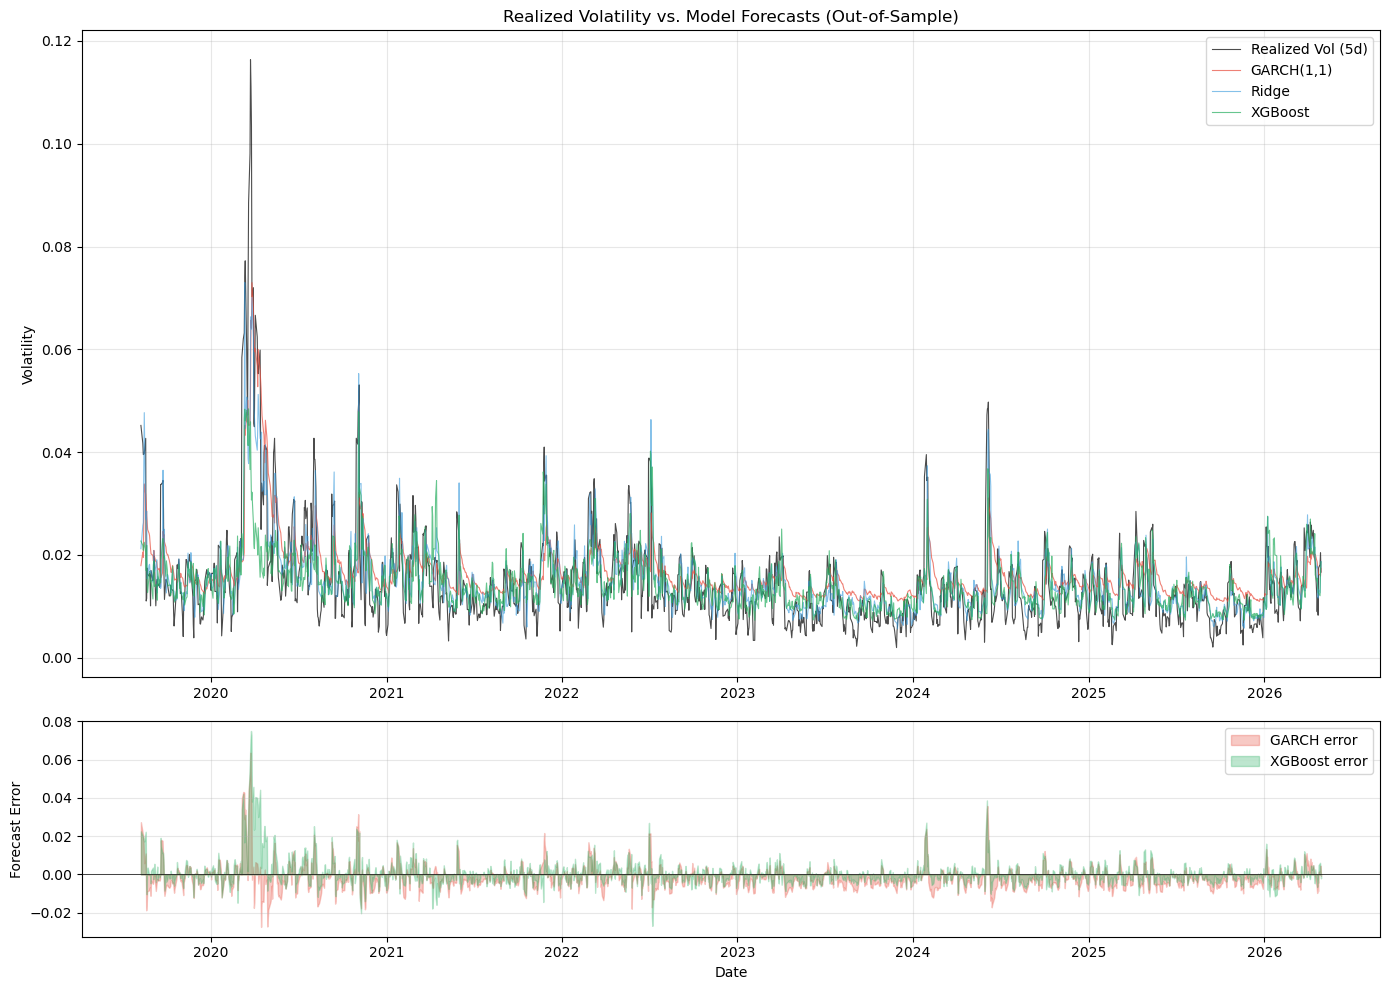

In [17]:
# Plot realized vol vs all three forecasts on the test folds
test_dates = xgb_predictions.index

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Panel 1: Forecasts vs realized
axes[0].plot(test_dates, y.loc[test_dates], color='black', linewidth=0.8, alpha=0.7, label='Realized Vol (5d)')
axes[0].plot(test_dates, df_clean.loc[test_dates, 'garch_vol'], color='#e74c3c', linewidth=0.8, alpha=0.7, label='GARCH(1,1)')
axes[0].plot(test_dates, ridge_predictions.loc[test_dates], color='#3498db', linewidth=0.8, alpha=0.6, label='Ridge')
axes[0].plot(test_dates, xgb_predictions.loc[test_dates], color='#27ae60', linewidth=0.8, alpha=0.7, label='XGBoost')
axes[0].set_ylabel('Volatility')
axes[0].set_title('Realized Volatility vs. Model Forecasts (Out-of-Sample)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: XGBoost forecast error
xgb_error = y.loc[test_dates] - xgb_predictions.loc[test_dates]
garch_error = y.loc[test_dates] - df_clean.loc[test_dates, 'garch_vol']
axes[1].fill_between(test_dates, garch_error, alpha=0.3, color='#e74c3c', label='GARCH error')
axes[1].fill_between(test_dates, xgb_error, alpha=0.3, color='#27ae60', label='XGBoost error')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vol_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Honest Reporting — Summary & Interpretation

In [19]:
# Final summary table
summary = pd.DataFrame({
    'Model': ['GARCH(1,1)', 'Ridge', 'XGBoost'],
    'Mean QLIKE': [garch_df['qlike'].mean(), ridge_df['qlike'].mean(), xgb_df['qlike'].mean()],
    'Mean MSE': [garch_df['mse'].mean(), ridge_df['mse'].mean(), xgb_df['mse'].mean()],
    'QLIKE Std': [garch_df['qlike'].std(), ridge_df['qlike'].std(), xgb_df['qlike'].std()],
})

summary['QLIKE vs GARCH (%)'] = ((summary['Mean QLIKE'] - summary['Mean QLIKE'].iloc[0]) / summary['Mean QLIKE'].iloc[0] * 100).round(2)

print("=" * 70)
print("FINAL RESULTS — ML vs GARCH Volatility Forecasting")
print("=" * 70)
print(f"\nStock: {ticker}")
print(f"Period: {start} to {end}")
print(f"Target: 5-day forward realized volatility")
print(f"Validation: TimeSeriesSplit, 5 folds")
print(f"Primary metric: QLIKE (lower = better)")
print()
print(summary.to_string(index=False))
print()

# Determine the actual outcome
best_model = summary.loc[summary['Mean QLIKE'].idxmin(), 'Model']
garch_qlike_mean = summary.loc[0, 'Mean QLIKE']
xgb_qlike_mean = summary.loc[2, 'Mean QLIKE']
ridge_qlike_mean = summary.loc[1, 'Mean QLIKE']

xgb_improvement = (garch_qlike_mean - xgb_qlike_mean) / garch_qlike_mean * 100
ridge_improvement = (garch_qlike_mean - ridge_qlike_mean) / garch_qlike_mean * 100

print("-" * 70)
print("INTERPRETATION")
print("-" * 70)

if xgb_improvement > 5:
    print(f"\nXGBoost improves on GARCH by {xgb_improvement:.1f}% QLIKE — a meaningful improvement.")
    print("The nonlinear combination of volatility features captures dynamics that")
    print("GARCH's parametric AR(1) variance equation misses.")
    print("\nThis is consistent with Hansen & Lunde (2005) and Christensen et al. (2023):")
    print("ML models can improve vol forecasts when given rich feature sets, especially")
    print("during regime transitions where GARCH's exponential decay assumption breaks down.")
elif xgb_improvement > 1:
    print(f"\nXGBoost improves on GARCH by {xgb_improvement:.1f}% QLIKE — marginal improvement.")
    print("The ML model adds some signal beyond GARCH, but the gain is modest.")
    print("\nThis is the most common empirical outcome in the literature: ML models")
    print("can slightly improve on GARCH by combining multiple volatility horizons,")
    print("but GARCH's parametric structure already captures most of the conditional")
    print("variance dynamics. The improvement may not survive transaction costs in")
    print("a trading context.")
elif xgb_improvement > -1:
    print(f"\nXGBoost and GARCH are approximately tied (Δ = {xgb_improvement:.1f}% QLIKE).")
    print("The ML model doesn't meaningfully improve on GARCH's forecast.")
    print("\nThis is a legitimate negative result. GARCH(1,1) is a strong baseline for")
    print("single-stock volatility forecasting — its parametric form efficiently captures")
    print("volatility clustering, and the additional features don't add enough nonlinear")
    print("signal to justify the added complexity.")
else:
    print(f"\nGARCH outperforms XGBoost by {-xgb_improvement:.1f}% QLIKE.")
    print("The ML model is worse than the baseline — likely overfitting to noise in")
    print("the training folds or suffering from the relatively small sample size.")
    print("\nThis outcome, while less discussed, is well-documented: Engle & Patton (2001)")
    print("showed that parsimonious volatility models often outperform flexible alternatives")
    print("on out-of-sample forecasting, especially for single-stock data.")

print(f"\nBest model: {best_model}")

FINAL RESULTS — ML vs GARCH Volatility Forecasting

Stock: RELIANCE.NS
Period: 2018-01-01 to 2026-05-01
Target: 5-day forward realized volatility
Validation: TimeSeriesSplit, 5 folds
Primary metric: QLIKE (lower = better)

     Model  Mean QLIKE  Mean MSE  QLIKE Std  QLIKE vs GARCH (%)
GARCH(1,1)    0.367640  0.000055   0.080972                0.00
     Ridge    0.300615  0.000042   0.055436              -18.23
   XGBoost    0.343570  0.000055   0.134625               -6.55

----------------------------------------------------------------------
INTERPRETATION
----------------------------------------------------------------------

XGBoost improves on GARCH by 6.5% QLIKE — a meaningful improvement.
The nonlinear combination of volatility features captures dynamics that
GARCH's parametric AR(1) variance equation misses.

This is consistent with Hansen & Lunde (2005) and Christensen et al. (2023):
ML models can improve vol forecasts when given rich feature sets, especially
during regime tr

## 9. Ridge Coefficient Analysis

Useful complement to XGBoost's feature importance — Ridge coefficients show the linear relationship direction and magnitude, which helps explain whether XGBoost's improvement (if any) comes from nonlinearity or just feature combination.

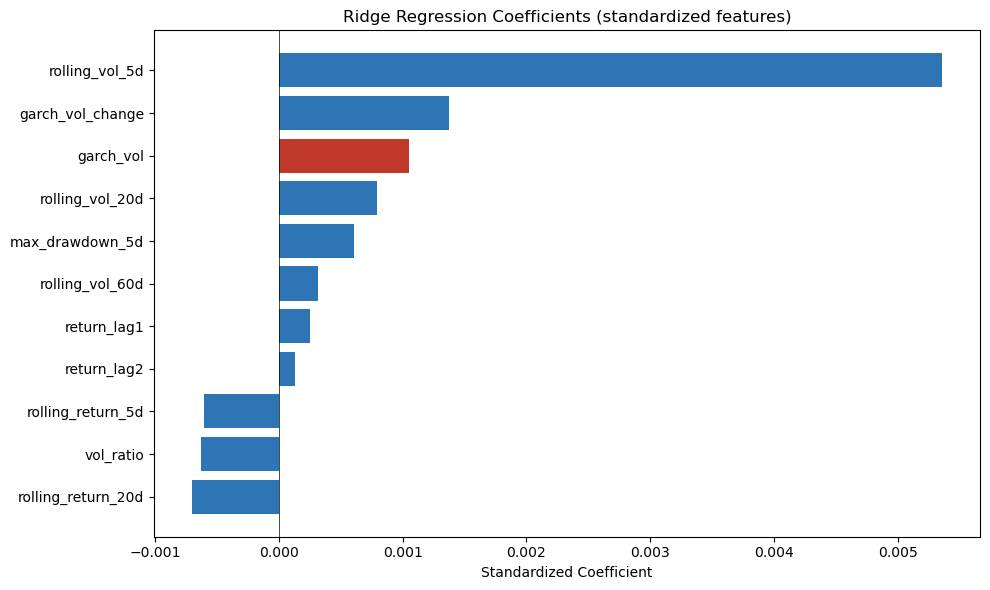


Ridge coefficients (standardized):
  rolling_vol_5d            +0.005363
  garch_vol_change          +0.001372
  garch_vol                 +0.001049 ← GARCH
  rolling_vol_20d           +0.000793
  max_drawdown_5d           +0.000608
  rolling_vol_60d           +0.000313
  return_lag1               +0.000249
  return_lag2               +0.000126
  rolling_return_5d         -0.000602
  vol_ratio                 -0.000626
  rolling_return_20d        -0.000706


In [21]:
# Fit Ridge on full data to inspect coefficients
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
ridge_full = Ridge(alpha=1.0)
ridge_full.fit(X_scaled_full, y)

ridge_coefs = pd.Series(ridge_full.coef_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = ['#c0392b' if feat == 'garch_vol' else '#2e75b6' for feat in ridge_coefs.index]
ax.barh(range(len(ridge_coefs)), ridge_coefs.values, color=colors_coef)
ax.set_yticks(range(len(ridge_coefs)))
ax.set_yticklabels(ridge_coefs.index)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Ridge Regression Coefficients (standardized features)')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('vol_forecast_ridge_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRidge coefficients (standardized):")
for feat, coef in ridge_coefs.sort_values(ascending=False).items():
    marker = " ← GARCH" if feat == 'garch_vol' else ""
    print(f"  {feat:25s} {coef:+.6f}{marker}")